In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import pandas as pd
import tensorflow as tf
from src.NN_Utils import TimeSeriesRandomSearch, make_build_model
from src.Utils import plot_performance_analysis
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score

In [2]:
X = pd.read_csv('../dataset/dataset_in.txt', index_col=0).drop(columns=['P2', 'Q2'])
y_columns = [f'V{i}' for i in range(2,15)] + ['PERD', 'QGEN7'] #V1 ES SIEMPRE 1.0 EN DATASET
Y = pd.read_csv('../dataset/dataset_out.txt', index_col=0).loc[:, y_columns]
#FILTRAR DATOS ERRÓNEOS (PÉRDIDAS NEGATIVAS)
mask = Y['PERD'] >= 0
X = X[mask]
Y = Y[mask]

In [3]:
n_samples = X.shape[0]
train_size = int(n_samples * 0.8)
x_train, y_train = X[:train_size], Y[:train_size]
x_test, y_test = X[train_size:], Y[train_size:]

In [4]:
input_dim = x_train.shape[1]
num_volts = len([c for c in y_train.columns if c.startswith('V')])
normalizer_layer = tf.keras.layers.Normalization(axis=-1)
normalizer_layer.adapt(x_train.values)
builder_function = make_build_model(input_dim, num_volts, normalizer_layer)

y_train_qgen = y_train[['QGEN7']]
y_train_perd = y_train[['PERD']]
y_train_volt = y_train.drop(columns=['QGEN7', 'PERD'])

tuner = TimeSeriesRandomSearch(builder_function, objective='val_loss', max_trials=10, overwrite=True, project_name='nn_random_search', seed=42)

In [5]:
tuner.search(
    x_train,
    y={
        'out_volt': y_train_volt,
        'out_perd': y_train_perd,
        'out_qgen7': y_train_qgen,
    },
    epochs=10,
    batch_size=32
)

Trial 10 Complete [00h 03m 14s]
val_loss: 0.012753508053719997

Best val_loss So Far: 0.00934793073683977
Total elapsed time: 00h 22m 25s


In [6]:
best_random_model = tuner.oracle.get_best_trials(1)[0]
for metric_name in best_random_model.metrics.metrics.keys():
    val = best_random_model.metrics.get_best_value(metric_name)
    print(f"{metric_name}: {val:.5f}")

val_loss: 0.00935
val_out_perd_loss: 0.00028
val_out_perd_mae: 0.01014
val_out_perd_mape: 5.59198
val_out_perd_r2_score: 0.98805
val_out_qgen7_loss: 0.00795
val_out_qgen7_mae: 0.05352
val_out_qgen7_mape: 8.88151
val_out_qgen7_r2_score: 0.79450
val_out_volt_loss: 0.00084
val_out_volt_mae: 0.02181
val_out_volt_mape: 83.60271
val_out_volt_r2_score: 0.96208


In [7]:
best_random_hp = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = builder_function(best_random_hp)
normalizer_qgen = MinMaxScaler(feature_range=(0, 1))
normalizer_volts = MinMaxScaler(feature_range=(0, 1))
normalizer_perd = MinMaxScaler(feature_range=(0, 1))
y_train_qgen_norm = normalizer_qgen.fit_transform(y_train_qgen)
y_train_perd_norm = normalizer_perd.fit_transform(y_train_perd)
y_train_volt_norm = normalizer_volts.fit_transform(y_train_volt)

In [8]:
results = best_model.fit(
    x_train,
    {
        'out_qgen7': y_train_qgen_norm,
        'out_volt': y_train_volt_norm,
        'out_perd': y_train_perd_norm
    },
    epochs=20,
    batch_size=32,
    validation_split=0.15,
    verbose=1
)

Epoch 1/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0436 - out_perd_loss: 0.0016 - out_perd_mae: 0.0278 - out_perd_mape: 557.6000 - out_perd_r2_score: 0.7936 - out_qgen7_loss: 0.0230 - out_qgen7_mae: 0.0980 - out_qgen7_mape: 11006.0234 - out_qgen7_r2_score: 0.4022 - out_volt_loss: 0.0175 - out_volt_mae: 0.0705 - out_volt_mape: 2339.6660 - out_volt_r2_score: -0.1206 - val_loss: 0.0143 - val_out_perd_loss: 6.7035e-04 - val_out_perd_mae: 0.0208 - val_out_perd_mape: 16.0361 - val_out_perd_r2_score: 0.9123 - val_out_qgen7_loss: 0.0110 - val_out_qgen7_mae: 0.0689 - val_out_qgen7_mape: 11.9572 - val_out_qgen7_r2_score: 0.7163 - val_out_volt_loss: 0.0020 - val_out_volt_mae: 0.0344 - val_out_volt_mape: 6.4716 - val_out_volt_r2_score: 0.8751
Epoch 2/20
2230/2230 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0129 - out_perd_loss: 6.0263e-04 - out_perd_mae: 0.0186 - out_perd_mape: 819.5803 - out_perd_r2_score: 0.9205 - out_qgen7_loss: 0.0103 - out_qgen7_mae: 0.0657 - out_qgen7_mape: 13020

In [9]:
best_model.save('../models/MO_NeuralNetwork.keras')

In [10]:
predictions = best_model.predict(x_test)
pred_volts_norm = predictions[0]
pred_perd_norm = predictions[1]
pred_qgen_norm = predictions[2]
y_pred_volts = normalizer_volts.inverse_transform(pred_volts_norm)
y_pred_perd = normalizer_perd.inverse_transform(pred_perd_norm)
y_pred_qgen = normalizer_qgen.inverse_transform(pred_qgen_norm)
y_pred = pd.DataFrame(np.hstack([y_pred_volts, y_pred_perd, y_pred_qgen]), columns=y_test.columns, index=y_test.index)

656/656 ━━━━━━━━━━━━━━━━━━━━ 1s 717us/step


In [13]:
evaluate_MAE = mean_absolute_error(y_test, y_pred, multioutput='raw_values')
#DESPLAZAMIENTO PARA EVITAR DIVISIÓN POR VALORES CERCANO A 0. CONSECUENCIA: MAPE ALGO OPTIMISTA
evaluate_MAPE = mean_absolute_percentage_error(y_test + 1.0, y_pred + 1.0, multioutput='raw_values')
evaluate_R2 = r2_score(y_test, y_pred, multioutput='raw_values')
evaluate_data_score = np.vstack([evaluate_MAE, evaluate_MAPE, evaluate_R2])
evaluations = pd.DataFrame(evaluate_data_score, columns=y_columns, index=['MAE', 'MAPE', 'R2'])
evaluations

,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,PERD,QGEN7
MAE,0.001840,0.001793,0.001795,0.001784,0.001770,0.001814,0.001766,0.001757,0.001787,0.001839,0.001774,0.001112,0.001145,0.136392,0.009814
MAPE,0.000932,0.000909,0.000910,0.000905,0.000898,0.000920,0.000895,0.000891,0.000906,0.000932,0.000900,0.000561,0.000578,0.015581,0.009267
R2,0.970512,0.971989,0.972152,0.972498,0.972795,0.971689,0.972990,0.973112,0.972445,0.971126,0.972782,0.985626,0.984656,0.983341,0.857167


In [15]:
volts_columns = [c for c in y_train.columns if c.startswith('V')]
pd.DataFrame({
    'Voltajes': evaluations[volts_columns].mean(axis=1),
    'Pérdidas': evaluations['PERD'],
    'Potencia Reactiva': evaluations['QGEN7']
})

,Voltajes,Pérdidas,Potencia Reactiva
MAE,0.001690,0.136392,0.009814
MAPE,0.000857,0.015581,0.009267
R2,0.974182,0.983341,0.857167


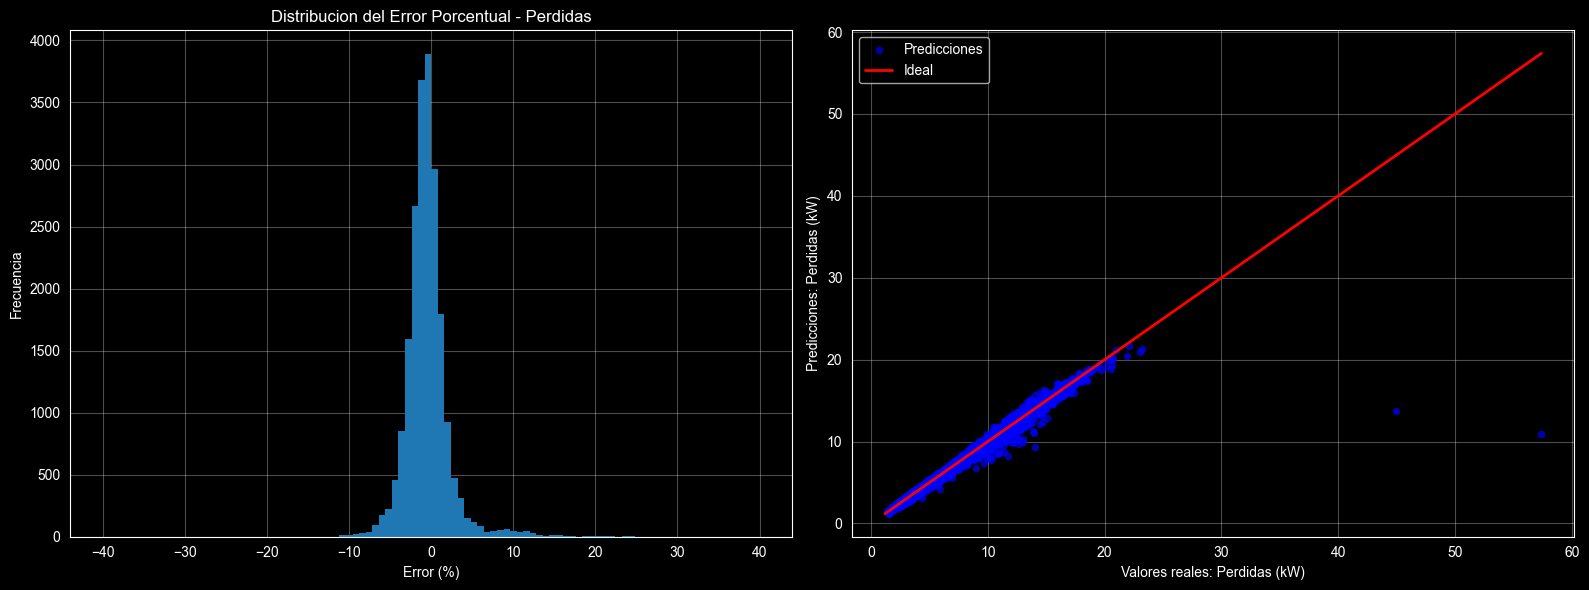

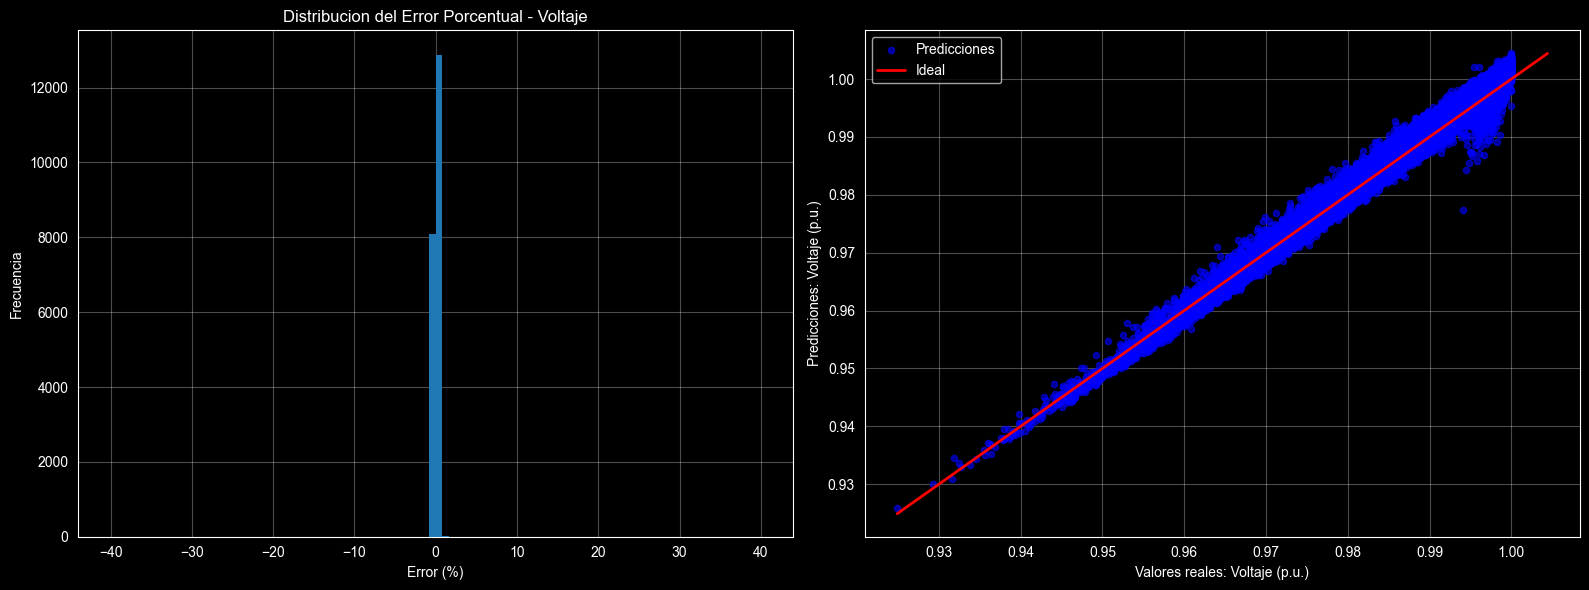

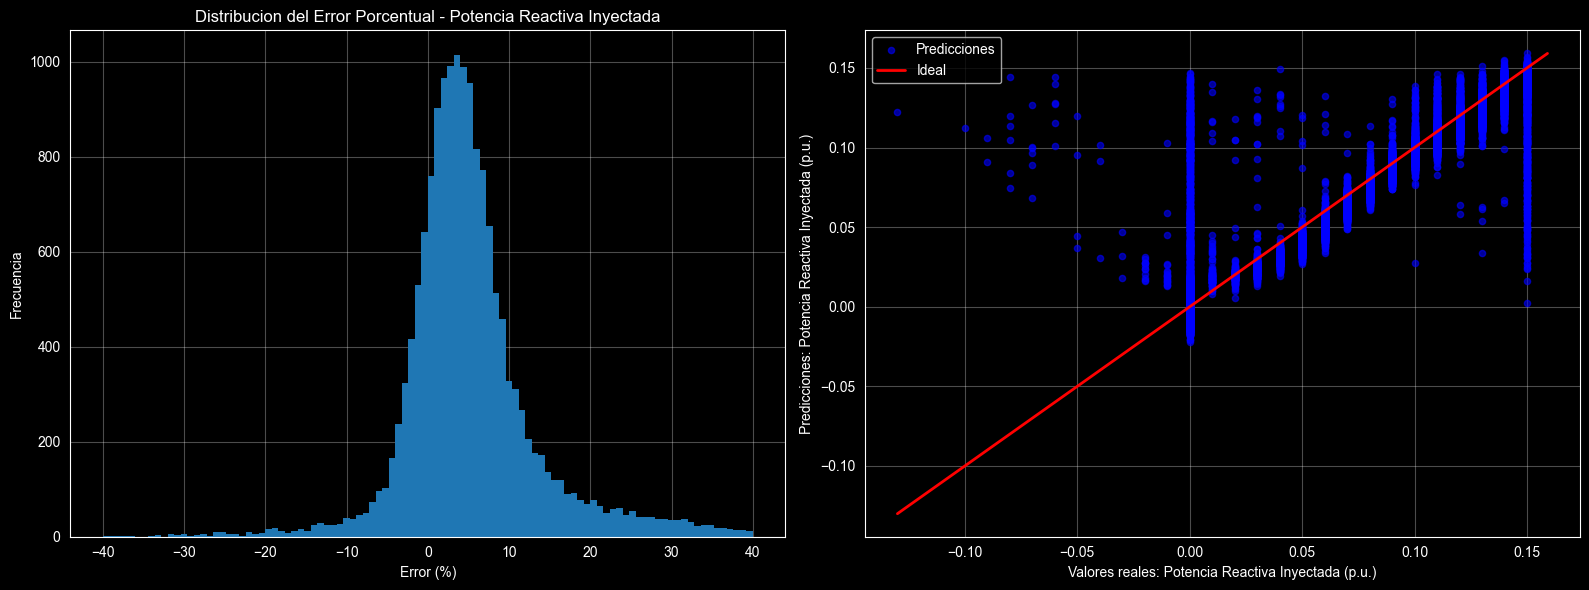

In [20]:
plot_performance_analysis(
    y_test['PERD'],
    y_pred.iloc[:, -2],
    variable_name="Perdidas",
    unit_label="kW",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_Perd.png'
)
plot_performance_analysis(
    y_test['V13'],
    y_pred.loc[:, 'V13'],
    variable_name="Voltaje",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_V13.png'
)
plot_performance_analysis(
    y_test['QGEN7'],
    y_pred.iloc[:, -1],
    variable_name="Potencia Reactiva Inyectada",
    unit_label="p.u.",
    path='../figures/NeuralNetwork/MO_NeuralNetwork_QGen.png'
)